# NeuroSegment-BraTS: Segmentação de Gliomas via Deep Learning

**Disciplina:** Aprendizagem de Máquinas 

**Instituição:** Universidade Federal Rural de Pernambuco (UFRPE)  

**Grupo:** 
* Beatriz Silva
* Éverton da Silva
* Leonardo Viana
* Nicholas Camargo

## 1. Definição do Problema e Dados
Este projeto foca na segmentação automatizada de tumores cerebrais (Gliomas) utilizando o dataset **BraTS 2020**. O objetivo é identificar áreas de necrose, edema e tumor realçado em imagens de Ressonância Magnética (MRI).

### O Dataset (Dados Brutos)
Diferente de bases de dados pré-processadas em imagens 2D, optamos por utilizar os dados originais da competição do MICCAI. Os dados estão estruturados no formato médico padrão NIfTI (`.nii` ou `.nii.gz`). Cada paciente possui um volume cerebral completo em 3D, composto por:
* **4 Modalidades de Ressonância:** FLAIR, T1, T1ce (com contraste) e T2.
* **1 Máscara (Ground Truth):** O gabarito anotado pelos especialistas, separando as partes saudáveis e tumorais do cérebro.

## 2. Bibliotecas e Configurações

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Caminho relativo apontando para a pasta raw (voltando um nível a partir da pasta notebooks)
DATA_PATH = '../data/raw/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

## 3. Leitura Crua e Inspeção
Nesta etapa, vamos listar os pacientes disponíveis e abrir os arquivos de um paciente de exemplo para entender a estrutura dos tensores tridimensionais (Largura x Altura x Profundidade/Fatias).

In [3]:
# Buscando as pastas dos pacientes
patient_folders = sorted(glob.glob(os.path.join(DATA_PATH, "BraTS20_Training_*")))
print(f"Total de pacientes encontrados: {len(patient_folders)}")

# Pegando o primeiro paciente como exemplo
sample_patient = patient_folders[0]
patient_id = os.path.basename(sample_patient)
print(f"Inspecionando paciente: {patient_id}\n")

# Construindo os caminhos para as 4 modalidades e a máscara
path_flair = os.path.join(sample_patient, f"{patient_id}_flair.nii")
path_t1    = os.path.join(sample_patient, f"{patient_id}_t1.nii")
path_t1ce  = os.path.join(sample_patient, f"{patient_id}_t1ce.nii")
path_t2    = os.path.join(sample_patient, f"{patient_id}_t2.nii")
path_seg   = os.path.join(sample_patient, f"{patient_id}_seg.nii")

# Carregando os volumes 3D usando nibabel (.get_fdata() converte para array NumPy)
vol_flair = nib.load(path_flair).get_fdata()
vol_t1    = nib.load(path_t1).get_fdata()
vol_t1ce  = nib.load(path_t1ce).get_fdata()
vol_t2    = nib.load(path_t2).get_fdata()
vol_seg   = nib.load(path_seg).get_fdata()

print(f"Shape do volume FLAIR: {vol_flair.shape} -> (Largura, Altura, Quantidade de Fatias)")
print(f"Shape do volume da Máscara: {vol_seg.shape}")

Total de pacientes encontrados: 369
Inspecionando paciente: BraTS20_Training_001

Shape do volume FLAIR: (240, 240, 155) -> (Largura, Altura, Quantidade de Fatias)
Shape do volume da Máscara: (240, 240, 155)


## 4. Visualização de Exemplo
Para visualizar o dado, precisamos fatiar o volume 3D. O cérebro completo possui 155 fatias no eixo Z. Abaixo, selecionamos uma fatia da região central (onde o tumor costuma ser visível) e plotamos as 4 modalidades lado a lado com o gabarito.

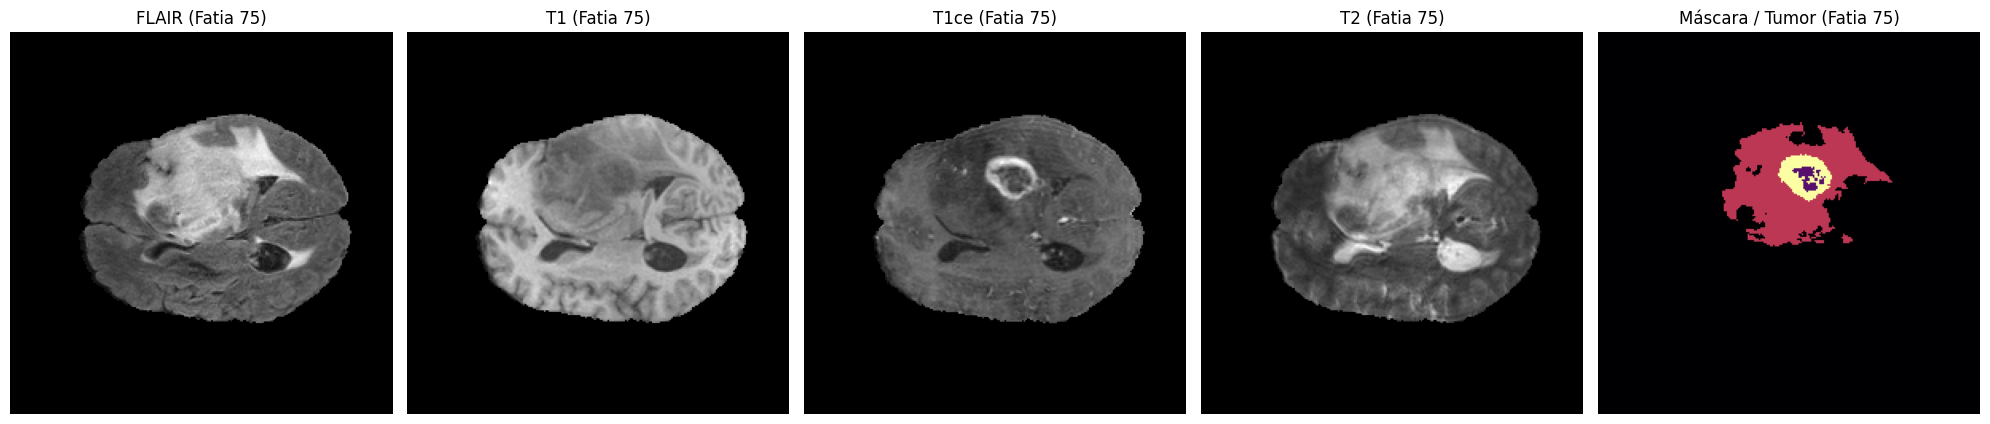

In [4]:
# Escolhendo a fatia 75 de 155 para visualização
slice_idx = 75

plt.figure(figsize=(20, 5))
modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
volumes = [vol_flair, vol_t1, vol_t1ce, vol_t2]

# Plot das 4 Modalidades
for i in range(4):
    plt.subplot(1, 5, i+1)
    plt.title(f"{modalities[i]} (Fatia {slice_idx})")
    plt.imshow(volumes[i][:, :, slice_idx], cmap='gray')
    plt.axis('off')

# Plot da Máscara (Ground Truth)
plt.subplot(1, 5, 5)
plt.title(f"Máscara / Tumor (Fatia {slice_idx})")
# Usamos o cmap 'inferno' ou 'jet' para destacar as diferentes classes de tecido tumoral
plt.imshow(vol_seg[:, :, slice_idx], cmap='inferno')
plt.axis('off')

plt.tight_layout()
plt.show()